In [123]:
from sklearn.tree import DecisionTreeClassifier
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

In [124]:
data = pd.read_csv("heart.csv")
data

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [125]:
x = data.iloc[:,:-1]
y = data.iloc[:,-1]


In [126]:
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.30)

In [127]:
dt = DecisionTreeClassifier(max_depth=6)
dt

DecisionTreeClassifier(max_depth=6)

In [128]:
dt.fit(x_train,y_train)
y_pred = dt.predict(x_test)

In [129]:
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score
confusion_matrix(y_pred,y_test)

array([[142,   9],
       [ 11, 146]])

In [130]:
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       0.93      0.94      0.93       151
           1       0.94      0.93      0.94       157

    accuracy                           0.94       308
   macro avg       0.94      0.94      0.94       308
weighted avg       0.94      0.94      0.94       308



In [131]:
# post - pruning --> it will grow tree till the end 
# pre - prining --> we will decide the depth of the tree in starting


In [132]:
from sklearn.tree import plot_tree

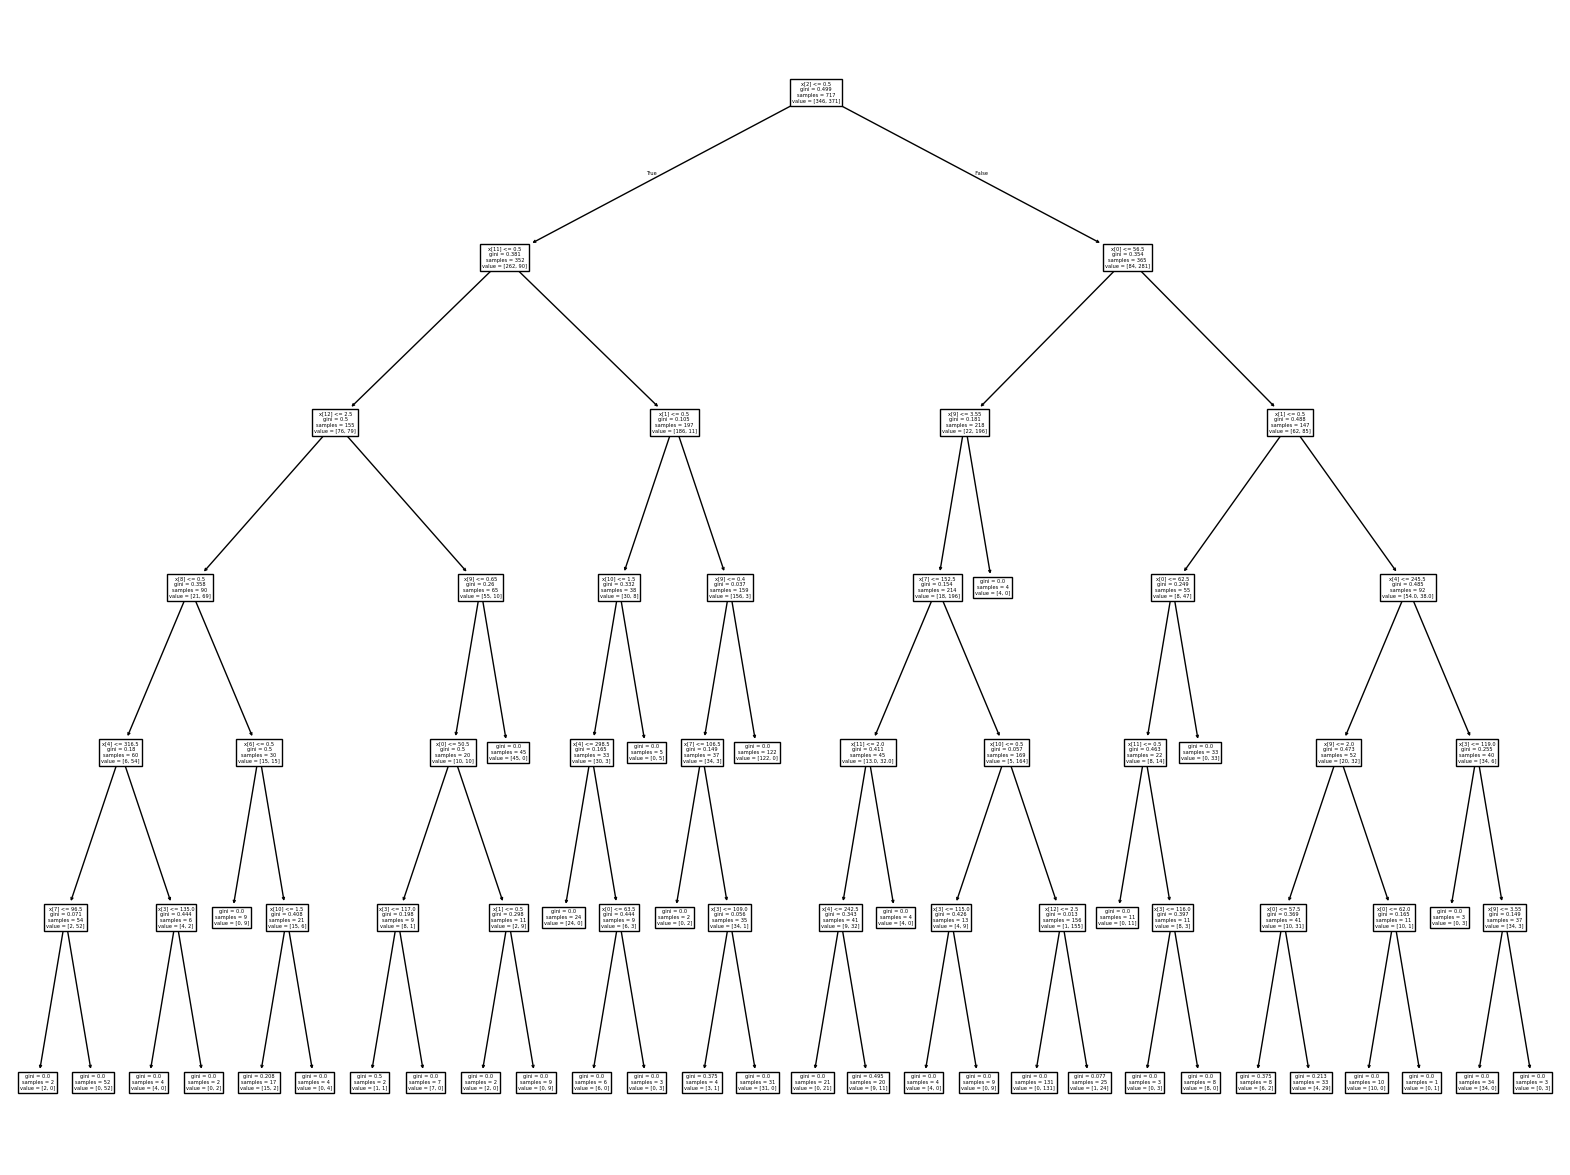

In [133]:
plt.figure(figsize=(20,15))
plot_tree(dt)
plt.show()

In [134]:
 # for pre - priuning --> gridsearchcv , and randomsearchcv

In [135]:
from sklearn.model_selection import GridSearchCV

In [136]:
modeldt = DecisionTreeClassifier()

In [137]:
params = {"criterion":["gini","entropy"],
              "max_depth":[5,6,7,8,9,10,11]}

In [138]:
cv = GridSearchCV(estimator=modeldt,param_grid=params,scoring="accuracy",cv=5)

In [139]:
cv.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [5, 6, 7, 8, 9, 10, 11]},
             scoring='accuracy')

In [140]:
cv.best_params_

{'criterion': 'gini', 'max_depth': 11}

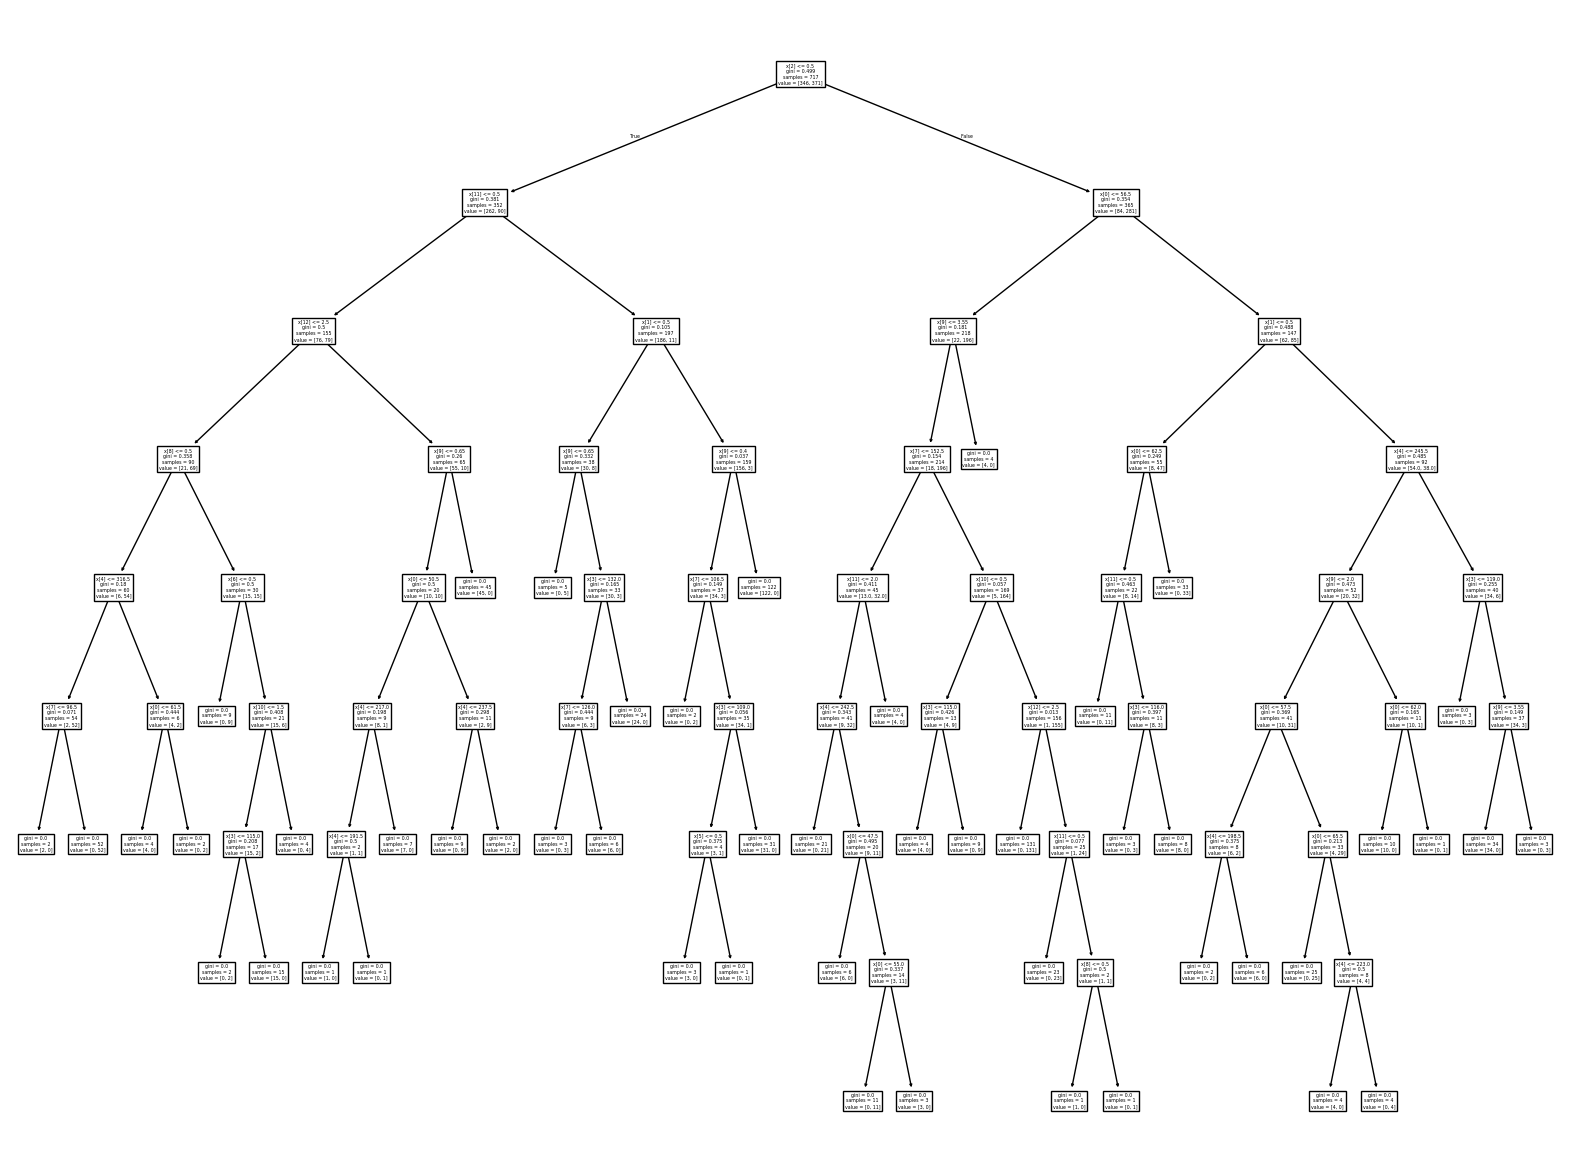

In [142]:
model = DecisionTreeClassifier(criterion="gini",max_depth=10)
model.fit(x_train,y_train)
plt.figure(figsize=(20,15))
plot_tree(model)
plt.show()